In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
pd.set_option('display.max_columns', None)

In [2]:
def null_percentage(df):
    """
    Returns a DataFrame with the percentage of null (NaN) values per column.
    """
    percentage = df.isnull().mean() * 100
    return percentage.to_frame(name='Null Percentage')


def zero_percentage(df):
    """
    Returns a DataFrame with the percentage of zero values per column.
    """
    percentage = (df == 0).mean() * 100
    return percentage.to_frame(name='Zero Percentage')

# Lectura de Dataset

In [3]:
df = pd.read_csv("../Data/kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

# Verificación de cantidad de nulos y de zeros

In [7]:
null_percentage(df)

,Null Percentage
id,0.0
date,0.0
price,0.0
bedrooms,0.0
bathrooms,0.0
sqft_living,0.0
sqft_lot,0.0
floors,0.0
waterfront,0.0
view,0.0


In [8]:
zero_percentage(df)

,Zero Percentage
id,0.000000
date,0.000000
price,0.000000
bedrooms,0.060149
bathrooms,0.046268
sqft_living,0.000000
sqft_lot,0.000000
floors,0.000000
waterfront,99.245824
view,90.172581


* Por valores en nulo no se elimina nada.
* Por valores en "0" se eliminan: waterfront, view, yr_renovated, sqft_basement

### Análisis de Varianza

In [ ]:
df['id'].value_counts()
# Alta varianza, por tanto se elimina

id
795000620     3
2231500030    2
1237500540    2
6117501820    2
7853420110    2
             ..
8091400200    1
3814700200    1
1202000200    1
1794500383    1
2008000270    1
Name: count, Length: 21436, dtype: int64

<Axes: xlabel='date'>

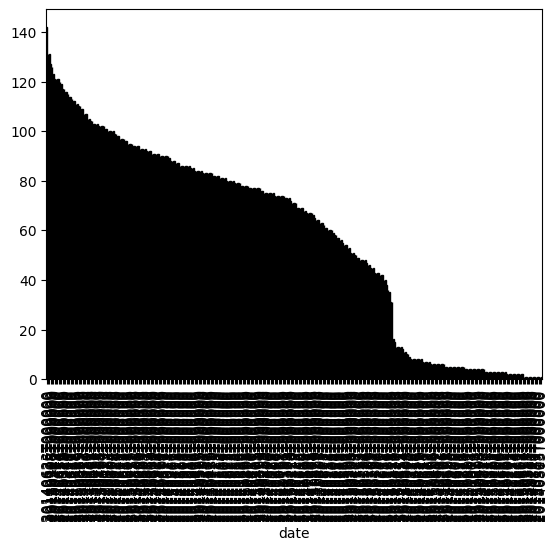

In [15]:
df['date'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

In [4]:
# Se puede extraer año y mes unicamente:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

C:\Users\Alex\AppData\Local\Temp\ipykernel_8740\511316658.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bedrooms', data=df, palette='pastel')


<Axes: xlabel='bedrooms', ylabel='count'>

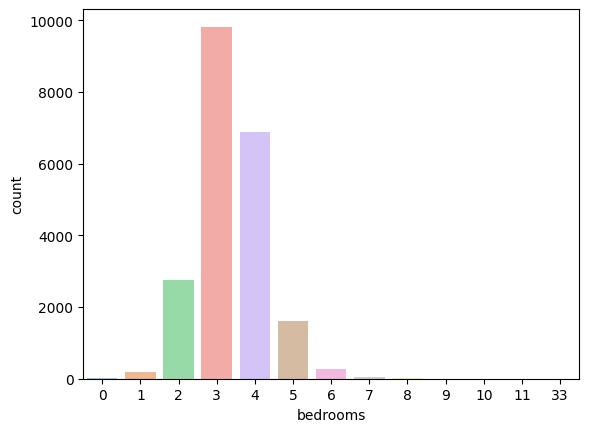

In [44]:
sns.countplot(x='bedrooms', data=df, palette='pastel')

In [45]:
df['bedrooms'].value_counts()

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

In [5]:
# Se eliminan posibles datos atipicos (outliers) o inconsistentes 
df = df[(df['bedrooms'] >= 1) & (df['bedrooms'] <= 6)]

## Variable Target

{'whiskers': [<matplotlib.lines.Line2D at 0x2894a2430d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2894ab5eb10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2894aa79890>],
 'medians': [<matplotlib.lines.Line2D at 0x2894ab60050>],
 'fliers': [<matplotlib.lines.Line2D at 0x2894ab60c90>],
 'means': []}

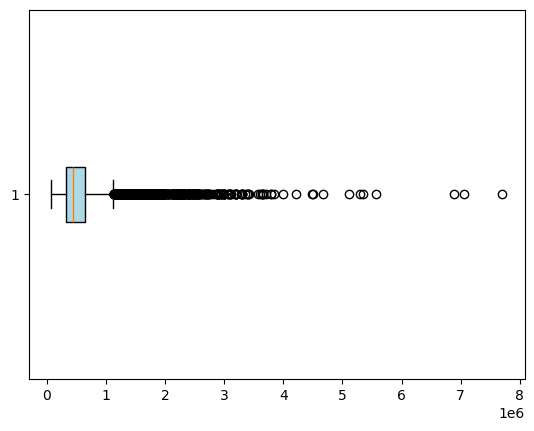

In [18]:
plt.boxplot(df['price'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))

In [6]:
# Se eliminan valores mayores a 3M, ya que son atipicos.
df_clean = df[df['price'] <= 3000000]

In [7]:
print("tamaño antes" , df.shape[0])

tamaño antes 21538


In [8]:
print("tamaño despues" ,df_clean.shape[0])

tamaño despues 21495


In [9]:
# ELIMINACION DE VARIABLES:
columns_to_drop = ['id', 'waterfront', 'view', 'yr_renovated', 'sqft_basement', 'date']
df_clean = df_clean.drop(columns=columns_to_drop)

In [10]:
df_clean.shape

(21495, 17)

In [11]:
df_clean.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'condition', 'grade', 'sqft_above', 'yr_built', 'zipcode', 'lat',
       'long', 'sqft_living15', 'sqft_lot15', 'year', 'month'],
      dtype='object')

In [15]:
df_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,221900.0,3,1.00,1180,5650,1.0,3,7,1180,1955,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,3,7,2170,1951,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,3,6,770,1933,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,5,7,1050,1965,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,3,8,1680,1987,98074,47.6168,-122.045,1800,7503,2015,2


# Preparación de datos

1. Se debe hacer imputacion en caso necesario.
2. Normalización.
3. Eliminacion de valores atipicos.

In [18]:
# NORMALIZACION
scaler = StandardScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)
df_normalized.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,-0.945069,-0.408870,-1.468413,-0.999017,-0.227511,-0.913391,-0.629757,-0.558578,-0.739718,-0.545379,1.869079,-0.350202,-0.306487,-0.944138,-0.260013,-0.691398,1.100353
1,0.017812,-0.408870,0.190747,0.567006,-0.189106,0.940735,-0.629757,-0.558578,0.482593,-0.681649,0.878592,1.161985,-0.746327,-0.429640,-0.187139,-0.691398,1.742262
2,-1.072702,-1.553377,-1.468413,-1.460937,-0.122573,-0.913391,-0.629757,-1.420320,-1.245927,-1.294863,-0.934188,1.283796,-0.136226,1.084455,-0.171641,1.446346,-1.467282
3,0.218856,0.735636,1.186244,-0.120241,-0.243191,-0.913391,2.444302,-0.558578,-0.900223,-0.204704,1.084165,-0.281007,-1.271298,-0.914738,-0.283828,-0.691398,1.742262
4,-0.067480,-0.408870,-0.141085,-0.435699,-0.168890,-0.913391,-0.629757,0.303163,-0.122389,0.544780,-0.074519,0.410937,1.197483,-0.267940,-0.192122,1.446346,-1.467282


# Analisis general

Se usa un algoritmo de clustering para hacer un análisis inicial.

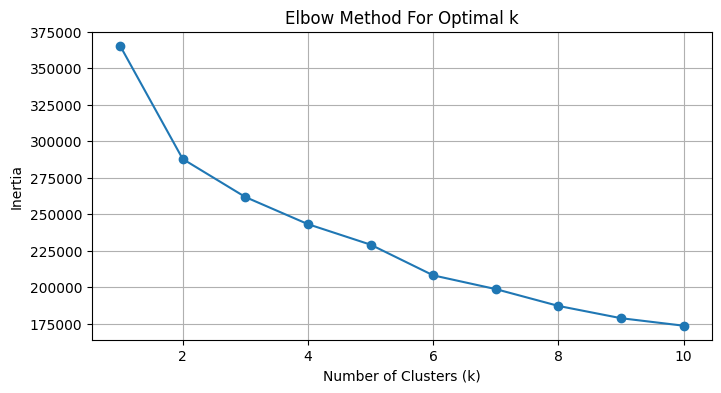

In [20]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_normalized)
    inertia.append(kmeans.inertia_)


# Graficar el resultado
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [25]:
# Asignar número de clusters
k = 3

# Entrenar modelo
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(df_normalized)

# Agregar columna de cluster al DataFrame original(df_clean), se hace asi para tener los datos sin normalizar
df_clustering = df_clean.copy()
df_clustering['cluster'] = kmeans.labels_

In [23]:
df_clustering['cluster'].value_counts()

cluster
1    8956
0    8184
2    4355
Name: count, dtype: int64

In [26]:
df_clustering.groupby('cluster').describe()

price                                                              \
          count           mean            std       min       25%       50%   
cluster                                                                       
0        8184.0  424265.725929  194318.568562   75000.0  276000.0  390000.0   
1        8956.0  434374.823024  165367.522175  115000.0  309740.0  405000.0   
2        4355.0  935974.988749  447422.103117  257000.0  645000.0  809950.0   

                              bedrooms                                     \
               75%        max    count      mean       std  min  25%  50%   
cluster                                                                     
0         535000.0  1545000.0   8184.0  2.960777  0.837413  1.0  2.0  3.0   
1         530000.0  1550000.0   8956.0  3.394484  0.747621  1.0  3.0  3.0   
2        1098000.0  3000000.0   4355.0  4.025718  0.745700  1.0  4.0  4.0   

                  bathrooms                                                  \
         75%  max     count      mean       std  min  25%   50%   75%   max   
cluster                                                                       
0        3.0  6.0    8184.0  1.487292  0.534514  0.0  1.0  1.50  1.75  4.00   
1        4.0  6.0    8956.0  2.278891  0.462326  0.5  2.0  2.50  2.50  5.25   
2        4.0  6.0    4355.0  2.914581  0.624990  1.0  2.5  2.75  3.25  6.50   

        sqft_living                                                           \
              count         mean         std     min     25%     50%     75%   
cluster                                                                        
0            8184.0  1499.756476  525.277864   370.0  1091.5  1410.0  1830.0   
1            8956.0  1958.480348  482.486633   490.0  1590.0  1930.0  2290.0   
2            4355.0  3354.790815  777.318999  1300.0  2820.0  3190.0  3720.0   

                sqft_lot                                                      \
            max    count          mean           std    min     25%      50%   
cluster                                                                        
0        3920.0   8184.0   8749.172654  19564.814984  520.0  4878.0   6731.0   
1        3890.0   8956.0  13275.097923  28816.391935  572.0  4750.0   7724.5   
2        8670.0   4355.0  30693.999311  75697.829365  609.0  6639.5  10160.0   

                              floors                                          \
              75%        max   count      mean       std  min  25%  50%  75%   
cluster                                                                        
0         8847.25  1164794.0  8184.0  1.168072  0.315021  1.0  1.0  1.0  1.5   
1        10520.00   542322.0  8956.0  1.597532  0.594743  1.0  1.0  2.0  2.0   
2        20580.00  1651359.0  4355.0  1.886797  0.382102  1.0  2.0  2.0  2.0   

             condition                                                grade  \
         max     count      mean       std  min  25%  50%  75%  max   count   
cluster                                                                       
0        3.0    8184.0  3.603372  0.749642  1.0  3.0  3.0  4.0  5.0  8184.0   
1        3.5    8956.0  3.306945  0.552666  1.0  3.0  3.0  4.0  5.0  8956.0   
2        3.0    4355.0  3.257176  0.538368  2.0  3.0  3.0  3.0  5.0  4355.0   

                                                       sqft_above  \
             mean       std  min  25%  50%   75%   max      count   
cluster                                                             
0        6.861070  0.732199  3.0  6.0  7.0   7.0  10.0     8184.0   
1        7.592899  0.672978  5.0  7.0  8.0   8.0  10.0     8956.0   
2        9.241102  1.000097  6.0  9.0  9.0  10.0  13.0     4355.0   

                                                                          \
                mean         std     min     25%     50%     75%     max   
cluster                                                                    
0        1225.064638  350.278753   3

ANALIZAR LOS RESULTADOS ANTERIORES PARA CADA CLUSTER

# División del conjunto para hacer entrenamiento:

In [28]:
y = df_clean['price']
X = df_clean.drop(columns=['price'])


# Paso 1: 80% Train + 20% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 2: del 80% original, saca 80% Train y 20% Validación
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# ✅ Resultado: 
# X_train: 64% del total
# X_val: 16% del total
# X_test: 20% del total

# Verifica tamaños si quieres:
print(f"Train: {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")

Train: 13756
Validation: 3440
Test: 4299


Se guardan para usar en otros modulos.

In [29]:
# 2. Unimos cada X con su y respectiva
train = pd.concat([X_train, y_train], axis=1)
val = pd.concat([X_val, y_val], axis=1)
test = pd.concat([X_test, y_test], axis=1)

# 3. Guardamos los archivos CSV
train.to_csv('../Data/train.csv', index=False)
val.to_csv('../Data/validation.csv', index=False)
test.to_csv('../Data/test.csv', index=False)

## Analisis de variables usando arbol de decision

In [31]:
# 1. Crear el modelo (para regresión, usa DecisionTreeRegressor)
model = DecisionTreeRegressor(max_depth=4, random_state=42)

# 2. Entrenar el modelo
model.fit(X_train, y_train)

# 3. Evaluar en validación (opcional)
score = model.score(X_val, y_val)
print(f"Validation R^2 Score: {score:.2f}")

Validation R^2 Score: 0.68


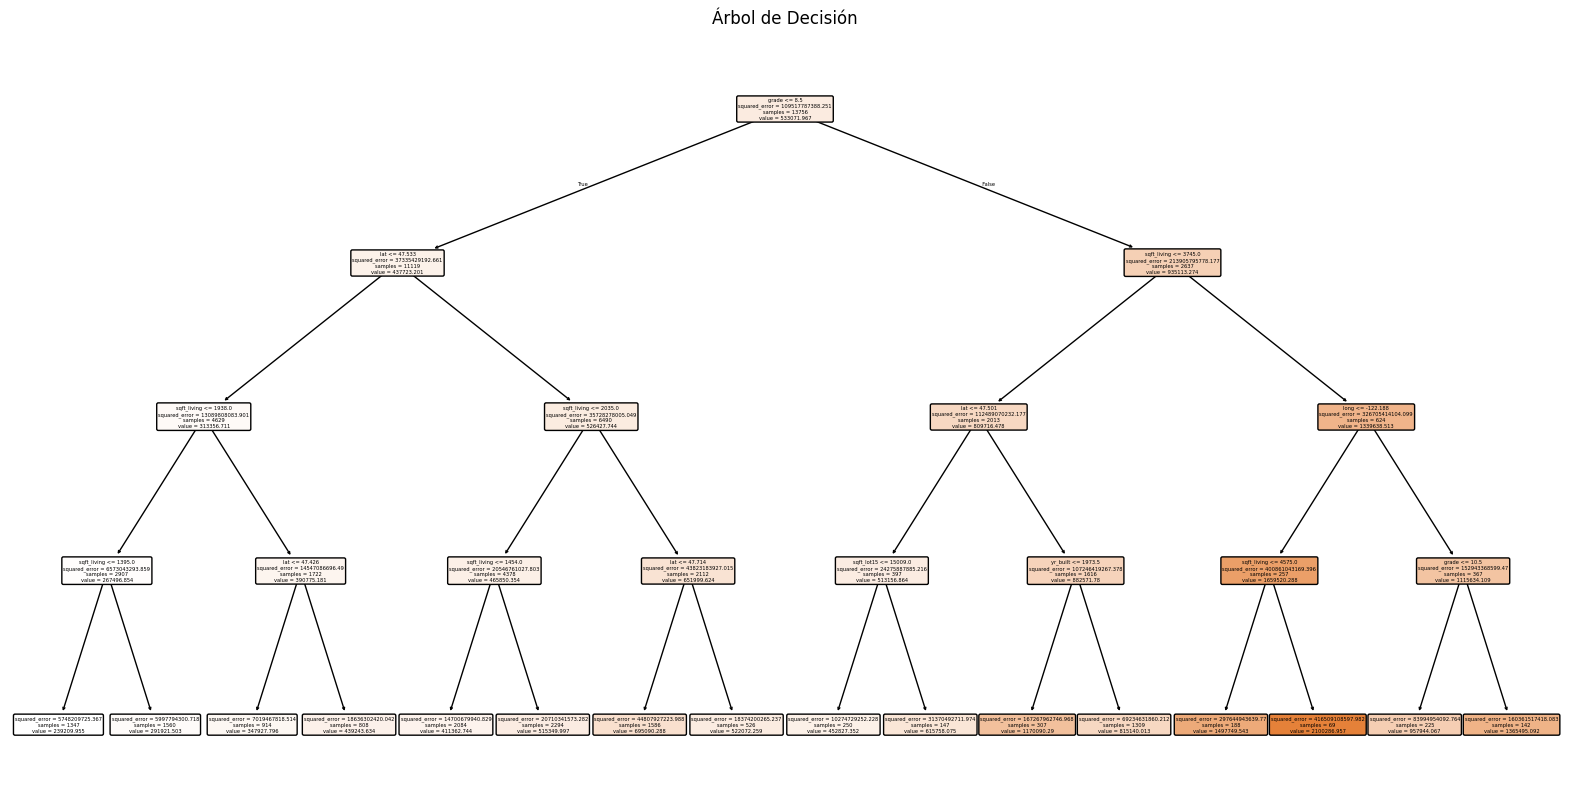

In [36]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Árbol de Decisión")
plt.savefig("../Data/arbol.jpg", format='jpg', dpi=300, bbox_inches='tight')

In [38]:
plt.close()  # Cierra la figura para liberar memoria

# Realizar análisis